# Imports

In [16]:
import os
import sys

In [17]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [18]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [19]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [21]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [22]:
dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j * Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

In [23]:
geom_f2d = Geometry(inc, pa, dra, ddec)

## F2D

In [77]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))

import math

N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [25]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536} # 8mins


## Performing with different rtols
This experiment makes sense when the tolerance for Ax = b is higher.

In [26]:
rtols = [1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]

In [27]:
times_rtol = []

In [28]:
frank_objects = []

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.05 seconds
        +  Building system = 0.04  min |  2.11 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 146/50000 [00:12<1:13:21, 11.33 iterations/s]


            +  BiCGStab = 0.21  min |  12.89 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 743.5963551417657,
 'iterations': 146,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-06}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.86 seconds
--> times building full visibility model = 0.11  min |  6.89 seconds


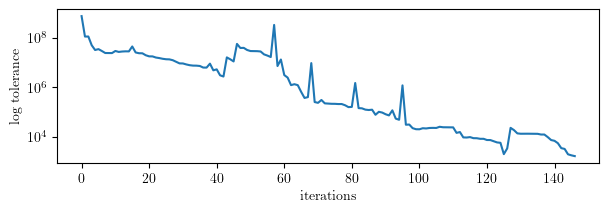

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.00 seconds
        +  Building system = 0.03  min |  2.06 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 191/50000 [00:15<1:05:37, 12.65 iterations/s]


            +  BiCGStab = 0.25  min |  15.10 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 74.35963551417657,
 'iterations': 191,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-07}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.85 seconds
--> times building full visibility model = 0.11  min |  6.88 seconds


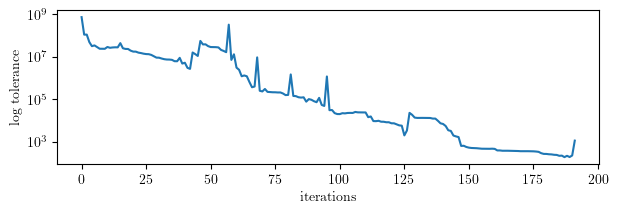

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.00 seconds
        +  Building system = 0.03  min |  2.06 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 225/50000 [00:17<1:05:40, 12.63 iterations/s]


            +  BiCGStab = 0.30  min |  17.81 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 225,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.88 seconds
--> times building full visibility model = 0.12  min |  6.91 seconds


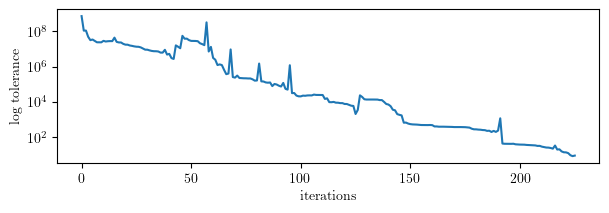

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +  Building system = 0.03  min |  2.05 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 259/50000 [00:20<1:05:22, 12.68 iterations/s]


            +  BiCGStab = 0.34  min |  20.42 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of r',
 'final_tol': 0.7435963551417658,
 'iterations': 259,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-09}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.86 seconds
--> times building full visibility model = 0.11  min |  6.89 seconds


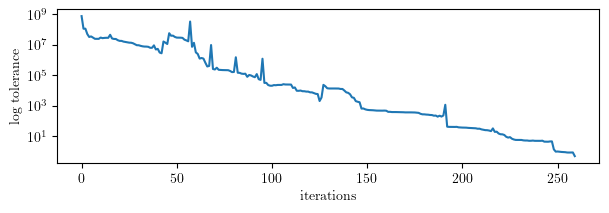

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +  Building system = 0.03  min |  2.05 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [00:22<1:05:23, 12.67 iterations/s]


            +  BiCGStab = 0.37  min |  22.02 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.87 seconds
--> times building full visibility model = 0.11  min |  6.90 seconds


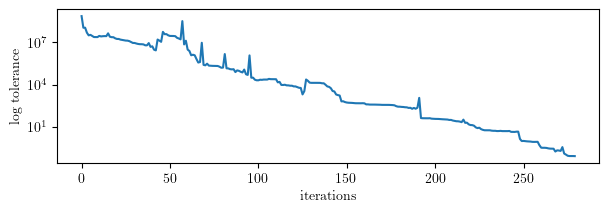

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +  Building system = 0.03  min |  2.04 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 327/50000 [00:26<1:07:48, 12.21 iterations/s]


            +  BiCGStab = 0.45  min |  26.79 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.007435963551417657,
 'iterations': 327,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-11}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.84 seconds
--> times building full visibility model = 0.11  min |  6.87 seconds


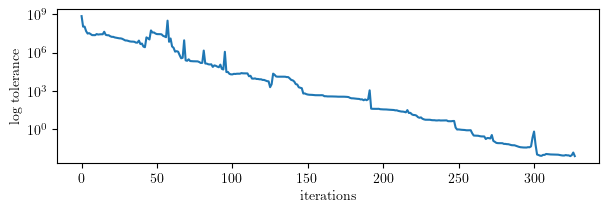

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +  Building system = 0.03  min |  2.05 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 357/50000 [00:28<1:06:21, 12.47 iterations/s]


            +  BiCGStab = 0.48  min |  28.63 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.0007435963551417657,
 'iterations': 357,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-12}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.83 seconds
--> times building full visibility model = 0.11  min |  6.86 seconds


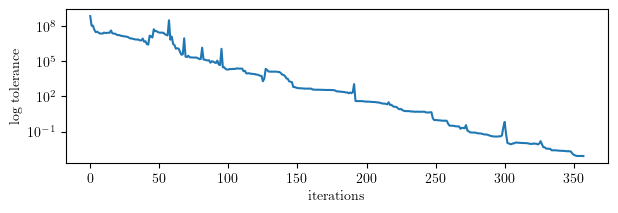

In [29]:
for i in rtols:
    start_time = time.time()
    frank2d = Frank2D(N, Rmax)
    frank2d.fit(uvtable, kernel_params = best_N50, rtol=i)
    Plot(frank2d, geom_f2d).cg_tolerance()
    end_time = time.time()
    times_rtol.append(end_time - start_time)
    frank_objects.append(frank2d)

In [30]:
iterations = []
converged = []

for i in frank_objects:
    iterations.append(i.solver.fit_info['iterations'])
    converged.append(i.solver.fit_info['Fit_correctly'])


In [31]:
marker_mask_times = np.where(converged, times_rtol, np.nan)
marker_mask_iter = np.where(converged, iterations, np.nan)

Text(0.5, 0, 'Tolerance')

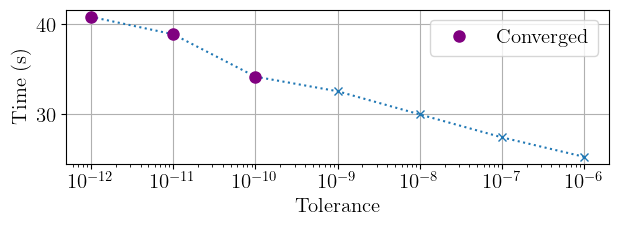

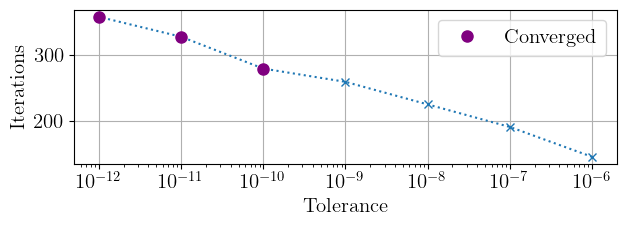

In [55]:
plt.figure(figsize=(7,2))
plt.plot(rtols, times_rtol, marker='x', ls=':')
#plt.yscale('log')
plt.xscale('log')
plt.ylabel(' Time (s)', size = 15)
plt.plot(rtols, marker_mask_times, 
         marker='o',
         linestyle='',
         color='purple',
         markersize=8, 
         label='Converged')
plt.legend(fontsize = 15)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel('Tolerance', size = 15)


plt.figure(figsize=(7,2))
plt.plot(rtols, iterations, marker='x', ls=':')
#plt.yscale('log')
plt.xscale('log')
plt.plot(rtols, marker_mask_iter, 
         marker='o',
         linestyle='',
         color='purple',
         markersize=8, 
         label='Converged')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.ylabel('Iterations', size = 15)
plt.legend(fontsize = 15)
plt.grid()
plt.xlabel('Tolerance', size = 15)



## Preconditioner


In [43]:
param_test = best_N50

#### jacobi



In [44]:
frank2d_jacobi = Frank2D(N, Rmax)
frank2d_jacobi.fit(uvtable, kernel_params = param_test, rtol= 1e-10, precond_type = 'jacobi')

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +  Building system = 0.03  min |  2.05 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [00:21<1:03:17, 13.09 iterations/s]


            +  BiCGStab = 0.36  min |  21.31 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.87 seconds
--> times building full visibility model = 0.12  min |  6.90 seconds


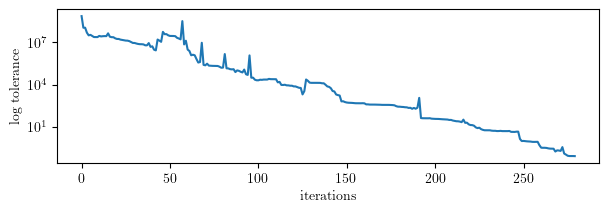

In [45]:
Plot(frank2d_jacobi, geom_f2d).cg_tolerance()


In [46]:
tols_jacobi = frank2d_jacobi.solver._fit_data['tols']
iterations_jacobi = range(1, frank2d_jacobi.solver._fit_info['iterations']+2)

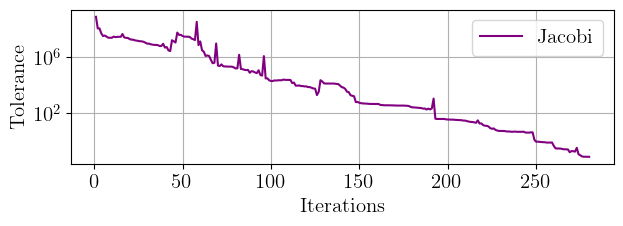

In [108]:
plt.figure(figsize=(7,2))
plt.plot(iterations_jacobi, tols_jacobi, ls='-', label='Jacobi', color = 'purple')
plt.yscale('log')
plt.ylabel(' Tolerance', size=15)
plt.xlabel('Iterations', size=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.grid()
plt.legend(fontsize=15)

#### ILU

In [48]:
frank2d_ilu = Frank2D(N, Rmax)
frank2d_ilu.fit(uvtable, kernel_params = param_test, rtol= 1e-10, precond_type = 'ilu')

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.99 seconds
        +   CSC = 0.00  min |  0.02 seconds
        +  ILU = 0.12  min |  7.29 seconds
        +  Building system = 0.16  min |  9.40 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 10/50000 [00:01<1:52:45,  7.39 iterations/s]


            +  BiCGStab = 0.02  min |  1.37 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 10,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.84 seconds
--> times building full visibility model = 0.11  min |  6.87 seconds


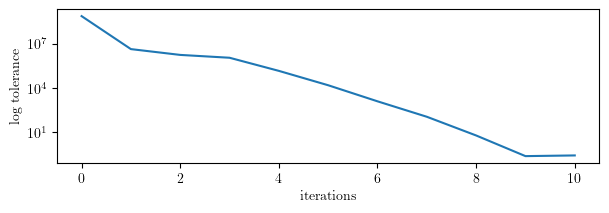

In [49]:
Plot(frank2d_ilu, geom_f2d).cg_tolerance()


In [50]:
tols_ilu = frank2d_ilu.solver._fit_data['tols']
iterations_ilu = range(1, frank2d_ilu.solver._fit_info['iterations']+2)

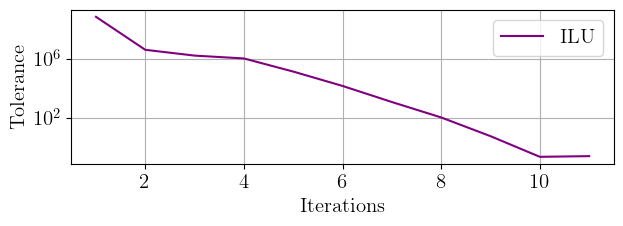

In [54]:
plt.figure(figsize=(7,2))
plt.plot(iterations_ilu, tols_ilu, ls='-', label='ILU', color = 'purple')
plt.yscale('log')
plt.ylabel(' Tolerance', size=15)
plt.xlabel('Iterations', size=15)
plt.legend(fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.grid()
plt.show()

## x0

#### Frank Parameters

In [56]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

In [57]:
import pickle

#### f1d sol

In [58]:
n_pts = N
alpha = 1.2
w_smooth = 1e-3

#geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
#FF = FrankFitter(rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
#f1d_sol = FF.fit(u, v, Vis, Weights)

In [59]:
#f1d_sol = sol

In [60]:
# save franksol
#with open(dir+'f1d_simulated_N300_a1p3_w1em3_r2.pkl', 'wb') as f:
#    pickle.dump(f1d_sol, f)

#### upload f1d sol

In [70]:
# upload pickle sol
import pickle
dir = "./../../data/"
with open(dir+'f1d/f1d_Simulated_N642_rout3_alpha1.2_ws0.001.pickle', 'rb') as f:
    f1d_sol = pickle.load(f)

#### create x0

In [78]:
n_pts = N

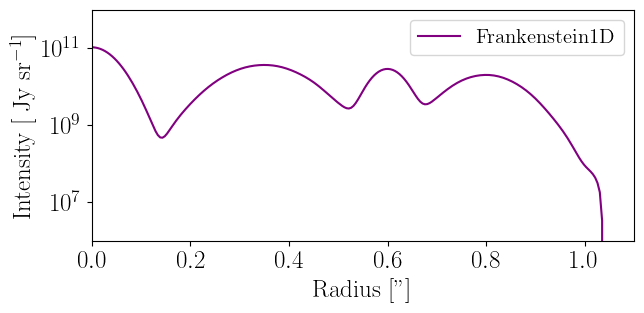

In [116]:
plt.figure(figsize = (7, 3))
plt.plot(f1d_sol.r, f1d_sol.mean,label = 'Frankenstein1D', color ='Purple')
plt.xlabel('Radius ["]', size = 18)
plt.ylabel(r'Intensity [ Jy sr$^{-1}$]', size = 18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.yscale("log")
plt.xlim(0, 1.1)
plt.ylim(1e6, 1e12)
plt.legend(fontsize=15)
plt.show()

In [80]:
frank2d_x0 = Frank2D(N, Rmax)
frank2d_x0.process_vis(uvtable)
u_gridded, v_gridded = frank2d_x0._gridded_data["u"], frank2d_x0._gridded_data['v']
vis_gridded, weights_gridded = frank2d_x0._gridded_data["vis"], frank2d_x0._gridded_data['weights']
q = np.hypot(u, v)

===>  Setting gridded data...


(-11035167.134219658, 11000789.666511808)

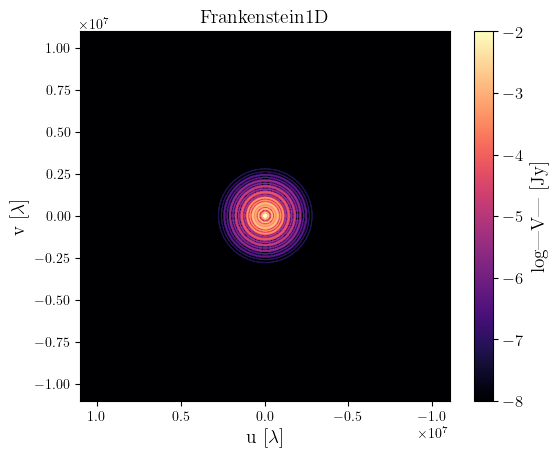

In [81]:
vis_fit_1d = f1d_sol.predict(u_gridded, v_gridded)

(-7356778.089479771, 7333859.777674538)

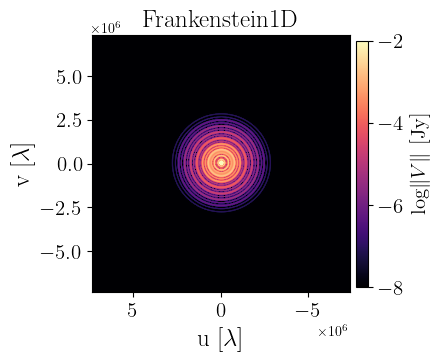

In [114]:
extent = [u_gridded.max(), u_gridded.min(), v_gridded.min(), v_gridded.max()]

plt.figure(figsize=(4,4))
plt.imshow(np.log(np.abs(vis_fit_1d.real.reshape(N, N))), 
           extent=extent, origin='lower', vmin=-8, vmax=-2, cmap='magma')

# 1. Asigna el colorbar a una variable 'cbar'
cbar = plt.colorbar(shrink=0.8, pad=0.02)

# 2. Configura el label y el tamaño aquí
cbar.set_label(r'log$\|V\|$ [Jy]', size=15) 

zoom = 1.5
cbar.ax.tick_params(labelsize=15)

plt.title('Frankenstein1D', size=18)
plt.xlabel(r'u [$\lambda$]', size=18)
plt.ylabel(r'v [$\lambda$]', size=18)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim(u_gridded.max()/zoom, u_gridded.min()/zoom)
plt.ylim(v_gridded.min()/zoom, v_gridded.max()/zoom)

#### run with x0

In [133]:
frank2d_x0.fit(uvtable, x0=vis_fit_1d, kernel_params = {'m':best_N50['m'], 'c':best_N50['c'], 'l': 1e5}, rtol=1e-10)

===>  Creating sparse linear system...


        +  Kernel = 0.07  min |  4.40 seconds
        +  Building system = 0.08  min |  4.60 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   3%|▎         | 1671/50000 [03:54<1:53:00,  7.13 iterations/s]


            +  BiCGStab = 3.91  min |  234.50 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 1671,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08,
 'using_x0': True}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.15  min |  8.86 seconds
--> times building full visibility model = 0.15  min |  8.94 seconds


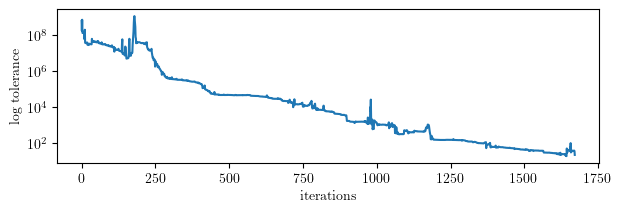

In [91]:
Plot_x0 = Plot(frank2d_x0, geom_f2d)
Plot_x0.cg_tolerance()

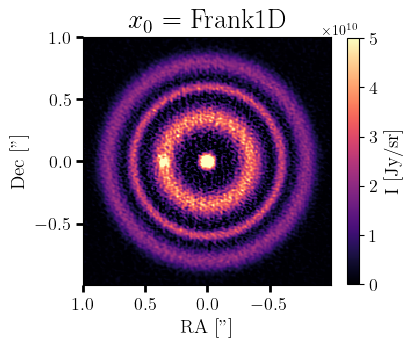

In [128]:
Plot_x0.intensity(vmax=5e10, gamma = 1, zoom = 3, title = r'$x_0$ = Frank1D', fig_size =4)


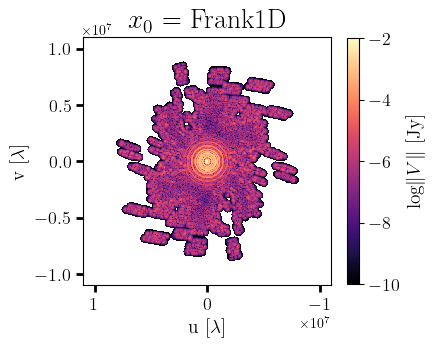

In [141]:
Plot_x0.visibility(fig_size = 4, zoom=1, title = r'$x_0$ = Frank1D')


##### run with dirty image

In [95]:
frank2d_with_x0_dirty = Frank2D(N, Rmax)
frank2d_with_x0_dirty.process_vis(uvtable)

vis_gridded = frank2d_with_x0_dirty._gridded_data['vis']
frank2d_with_x0_dirty.fit(kernel_params = best_N50, x0 = vis_gridded , rtol=1e-8)

===>  Setting gridded data...
===>  Setting guess...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.00 seconds
        +  Building system = 0.03  min |  2.06 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 213/50000 [00:18<1:10:30, 11.77 iterations/s]


            +  BiCGStab = 0.30  min |  18.12 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 7.435963551417657,
 'iterations': 213,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08,
 'using_x0': True}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  6.95 seconds
--> times building full visibility model = 0.12  min |  6.98 seconds


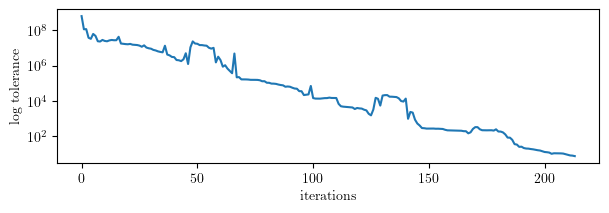

In [96]:
Plot_wit_x0_dirty = Plot(frank2d_with_x0_dirty, geom_f2d)
Plot_wit_x0_dirty.cg_tolerance()

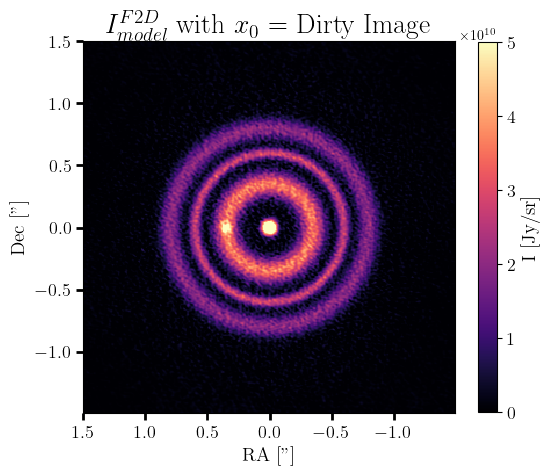

In [97]:
Plot_wit_x0_dirty.intensity(vmax=5e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$' + f' with $x_0$ = Dirty Image')

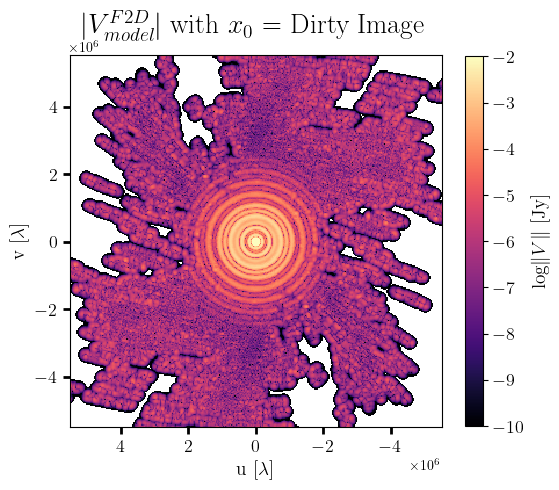

In [99]:
Plot_wit_x0_dirty.visibility(fig_size = 6, zoom =2, title = r'$|V_{model}^{F2D}|$' + f' with $x_0$ = Dirty Image')

##### run without x0

In [138]:
frank2d_without_x0 = Frank2D(N, Rmax)
frank2d_without_x0.fit(uvtable, kernel_params = best_N50, rtol=1e-10)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.09  min |  5.46 seconds
        +  Building system = 0.09  min |  5.54 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [01:12<3:35:28,  3.85 iterations/s]


            +  BiCGStab = 1.21  min |  72.58 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.29  min |  17.13 seconds
--> times building full visibility model = 0.29  min |  17.17 seconds


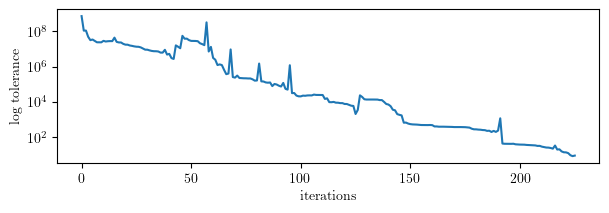

In [101]:
Plot_without_x0 = Plot(frank2d_without_x0, geom_f2d)
Plot_without_x0.cg_tolerance()

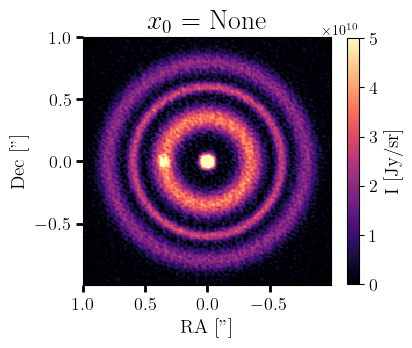

In [131]:
Plot_without_x0.intensity(vmax=5e10, gamma = 1, zoom = 3, title = r'$x_0$ = None', fig_size=4)


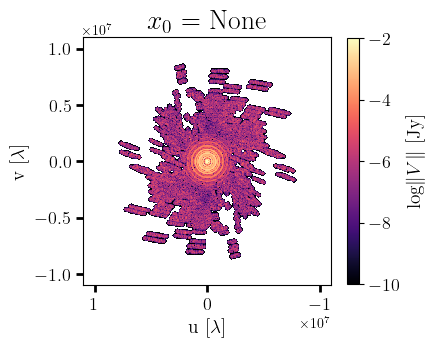

In [142]:
Plot_without_x0.visibility(fig_size = 4, zoom = 1, title = r'$x_0$ = None')

In [134]:
# make a copy of plot class

import copy
Plot_ = copy.deepcopy(Plot_without_x0)

In [135]:
Plot_._vis_model = Plot_x0._vis_model - Plot_without_x0._vis_model

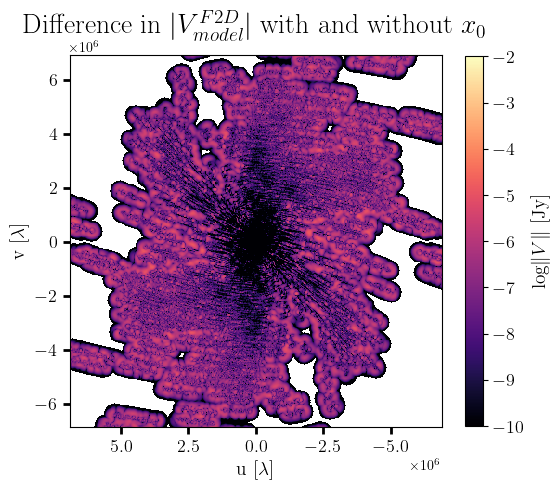

In [137]:
Plot_.visibility(fig_size = 6, zoom = 1.6, title = r'Difference in $|V_{model}^{F2D}|$' + r' with and without $x_0$')